Factor Loadings:
 [[-0.01403476  0.15530057]
 [ 0.05407664 -0.07428218]
 [ 0.04358995 -0.12837449]
 [-0.08562145  0.03869333]
 [-0.2679757  -0.05636837]]
Factor Scores:
 [[-0.17828162 -1.81243097]
 [-2.40611135 -2.12513806]
 [ 0.25594568 -3.4996122 ]
 [-0.93002033 -1.20465027]
 [-1.68592845  0.70137095]
 [-0.48688167  1.20879728]
 [-3.99794756  1.09505571]
 [-1.98602896  1.81220553]
 [-1.4334073  -0.03243096]
 [-0.78560258  0.46674184]
 [-1.99110041 -0.52545082]
 [-1.07722749  1.86740203]
 [-0.71867484 -1.3430651 ]
 [-2.80256228 -1.61276373]
 [-3.0784572   1.89343066]
 [-0.32126308  1.05840323]
 [-0.62689302  0.59442714]
 [-1.66134891 -1.53237678]
 [-2.19339954 -3.02839376]
 [ 0.10556996 -0.43564032]
 [-2.84059187 -2.24899541]
 [ 0.13555822 -1.65874264]
 [-2.30209551 -1.78697798]
 [-2.1576029   1.09908369]
 [-0.23189139  0.18544167]
 [-0.73313123 -2.62746364]
 [-3.21050061 -0.14075356]
 [-2.82053343 -2.34887029]
 [-0.95420522  1.23088787]
 [-0.2937255  -2.31927031]
 [-3.55873027  1.339

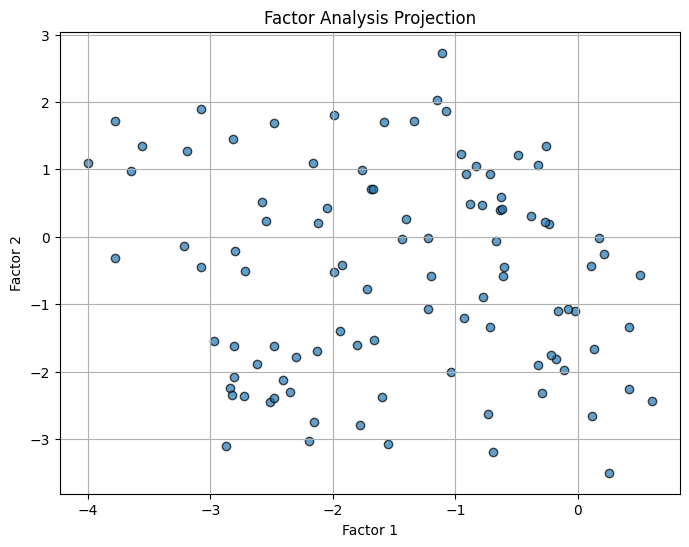

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def factor_analysis(X, n_factors, max_iter=100, tol=1e-6):
    """Performs Factor Analysis using an iterative EM-like approach."""
    n_samples, n_features = X.shape

    # Step 1: Compute the covariance matrix
    cov_matrix = np.cov(X, rowvar=False)

    # Step 2: Initialize unique variance (Psi) as diagonal elements
    unique_variance = np.diag(np.diag(cov_matrix))
    common_variance = cov_matrix - unique_variance  # Initial common variance

    for _ in range(max_iter):
        # Step 3: Eigendecomposition of common variance
        eigenvalues, eigenvectors = np.linalg.eigh(common_variance)
        idx = np.argsort(eigenvalues)[::-1]  # Sort in descending order
        eigenvalues, eigenvectors = eigenvalues[idx], eigenvectors[:, idx]

        # Step 4: Select top `n_factors` eigenvalues and eigenvectors
        selected_eigenvalues = eigenvalues[:n_factors]
        selected_eigenvectors = eigenvectors[:, :n_factors]

        # Step 5: Compute factor loadings L
        factor_loadings = selected_eigenvectors * np.sqrt(selected_eigenvalues)

        # Step 6: Update unique variance Psi
        new_unique_variance = np.diag(cov_matrix - factor_loadings @ factor_loadings.T)

        # Convergence check
        if np.linalg.norm(new_unique_variance - np.diag(unique_variance)) < tol:
            break

        unique_variance = np.diag(new_unique_variance)
        common_variance = cov_matrix - unique_variance  # Update common variance

    # Step 7: Compute Factor Scores Z (Least Squares Estimation)
    factor_scores = X @ np.linalg.pinv(factor_loadings.T)

    return factor_loadings, factor_scores

# Example usage
np.random.seed(42)
X = np.random.rand(100, 5)  # 100 samples, 5 observed variables
loadings, scores = factor_analysis(X, 2)

print("Factor Loadings:\n", loadings)
print("Factor Scores:\n", scores)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.7, edgecolors='k')
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factor Analysis Projection")
plt.grid(True)
plt.show()
